In [ ]:
!pip install -q datasets transformers

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import urllib.request
from collections import Counter
from sklearn.model_selection import train_test_split
from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
url_raw = "https://raw.githubusercontent.com/Flavio-98/financial-sentiment-analysis-transformers/main/FinancialPhraseBank-v1.0/Sentences_AllAgree.txt"

req = urllib.request.Request(url_raw, headers={'User-Agent': 'Mozilla/5.0'})
conteudo = urllib.request.urlopen(req).read().decode('latin-1')

dados = []
for linha in conteudo.splitlines():
    linha = linha.strip()
    if linha and '@' in linha:
        texto, rotulo = linha.rsplit('@', 1)
        dados.append({'texto': texto, 'rotulo_orig': rotulo})

df = pd.DataFrame(dados)

print(f"Total de frases: {len(df)}")
df.head()

Total de frases: 2264


,texto,rotulo_orig
0,"According to Gran , the company has no plans t...",neutral
1,"For the last quarter of 2010 , Componenta 's n...",positive
2,"In the third quarter of 2010 , net sales incre...",positive
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive


In [ ]:
mapa_sentimentos = {
    'negative': 'Negativo',
    'neutral': 'Neutro',
    'positive': 'Positivo'
}

df['sentimento'] = df['rotulo_orig'].map(mapa_sentimentos)

df[['texto', 'rotulo_orig', 'sentimento']].head()

,texto,rotulo_orig,sentimento
0,"According to Gran , the company has no plans t...",neutral,Neutro
1,"For the last quarter of 2010 , Componenta 's n...",positive,Positivo
2,"In the third quarter of 2010 , net sales incre...",positive,Positivo
3,Operating profit rose to EUR 13.1 mn from EUR ...,positive,Positivo
4,"Operating profit totalled EUR 21.1 mn , up fro...",positive,Positivo


In [ ]:
contagem = df['sentimento'].value_counts()
porcentagem = df['sentimento'].value_counts(normalize=True) * 100

resumo_classes = pd.DataFrame({
    'Quantidade': contagem,
    'Porcentagem (%)': porcentagem.round(2)
})

print("--- Distribuição dos Sentimentos ---")
display(resumo_classes)

--- Distribuição dos Sentimentos ---


,Quantidade,Porcentagem (%)
sentimento,,
Neutro,1391,61.44
Positivo,570,25.18
Negativo,303,13.38


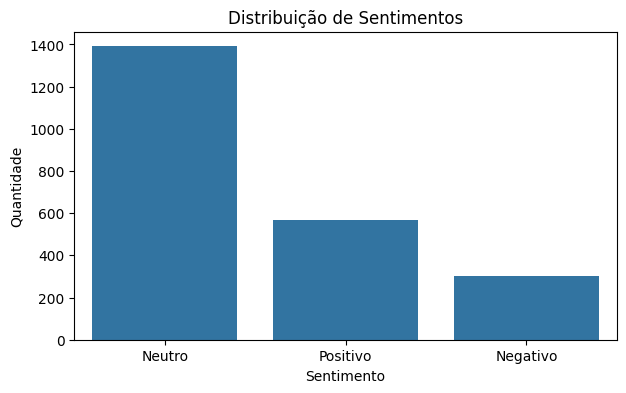

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='sentimento', order=['Neutro', 'Positivo', 'Negativo'])
plt.title('Distribuição de Sentimentos')
plt.xlabel('Sentimento')
plt.ylabel('Quantidade')
plt.show()

In [ ]:
df['qtd_palavras'] = df['texto'].str.split().str.len()

df['qtd_palavras'].describe()

,qtd_palavras
count,2264.000000
mean,22.441696
std,10.147048
min,2.000000
25%,15.000000
50%,21.000000
75%,28.000000
max,81.000000


In [ ]:
df.groupby('sentimento')['qtd_palavras'].mean().round(2)

,qtd_palavras
sentimento,
Negativo,24.80
Neutro,20.93
Positivo,24.88


In [ ]:
todas_palavras = " ".join(df['texto']).lower().split()
Counter(todas_palavras).most_common(10)

[('the', 2730),
 ('.', 2219),
 (',', 2140),
 ('of', 1525),
 ('in', 1384),
 ('and', 1166),
 ('to', 1081),
 ('eur', 756),
 ('a', 721),
 ('for', 541)]

In [ ]:
stopwords = {'the', 'of', 'in', 'and', 'to', 'a', 'for', 'is', 'on', 'with', 'by', 'at', 'from', 'as', 'an', 'that'}

palavras_limpas = [
    w for w in todas_palavras
    if w.isalpha() and len(w) > 2 and w not in stopwords
]

Counter(palavras_limpas).most_common(10)

[('eur', 756),
 ('company', 349),
 ('will', 346),
 ('profit', 322),
 ('net', 292),
 ('million', 266),
 ('sales', 260),
 ('its', 260),
 ('finnish', 219),
 ('said', 206)]

In [ ]:
for sent in ['Positivo', 'Negativo']:
    textos = " ".join(df[df['sentimento'] == sent]['texto']).lower().split()
    limpas = [w for w in textos if w.isalpha() and len(w) > 2 and w not in stopwords]
    print(f"--- Top 5 ({sent}) ---")
    print(Counter(limpas).most_common(5))
    print()

--- Top 5 (Positivo) ---
[('eur', 375), ('profit', 172), ('net', 166), ('sales', 129), ('period', 125)]

--- Top 5 (Negativo) ---
[('eur', 251), ('profit', 122), ('net', 84), ('sales', 72), ('operating', 68)]



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['texto'],
    df['sentimento'],
    test_size=0.2,
    random_state=42,
    stratify=df['sentimento']
)

print(f"Base de teste com {len(X_test)} frases.")

Base de teste com 453 frases.


In [ ]:
classificador = pipeline("sentiment-analysis", model="ProsusAI/finbert")

mapa_finbert = {'positive': 'Positivo', 'negative': 'Negativo', 'neutral': 'Neutro'}

resultados = classificador(list(X_test), truncation=True)
y_pred = [mapa_finbert[res['label']] for res in resultados]

print(f"Acurácia: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Acurácia: 96.91%

              precision    recall  f1-score   support

    Negativo       0.95      0.97      0.96        61
      Neutro       1.00      0.96      0.98       278
    Positivo       0.91      0.99      0.95       114

    accuracy                           0.97       453
   macro avg       0.95      0.97      0.96       453
weighted avg       0.97      0.97      0.97       453

